# External Tunable Approach

This notebook implements a tunable, macro-driven Bitcoin accumulation strategy and compares it against a Uniform DCA baseline. It utilizes external Treasury yield data to mathematically identify periods of cheap liquidity, dynamically scaling daily purchase weights to maximize performance.

# Load data

In [2]:
import sys
from pathlib import Path
import pandas as pd

# patch deprecate_kwarg regardless of pandas version for pandas_datareader compatibility
import pandas.util._decorators
pandas.util._decorators.deprecate_kwarg = lambda *args, **kwargs: lambda x: x
import pandas_datareader.data as web

import polars as pl
import warnings
from datetime import date
import matplotlib.pyplot as plt

_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

DATA_DIR = src_config.DATA_DIR
PROCESSED_DATA_PATH = DATA_DIR / "processed"
STACKSATS_DATA_PATH = src_config.STACKSATS_DATA_PATH
RAW_PATH = src_config.RAW_PATH

data_utils.check_stacksats_data(STACKSATS_DATA_PATH, RAW_PATH)

True

## Data download from Yahoo Finance

The data is already stored in a Google Drive folder. Re-running the cell below may lead to runtime issues because of Yahoo Finance rate limits. If you need to download additional economic metrics, please uncomment the code below.

In [2]:
# import polars as pl
# import pandas as pd
# import yfinance as yf
# import warnings
# warnings.filterwarnings('ignore')
# # 1. Load the original raw bitcoin data
# btc_df = pl.read_parquet(DATA_DIR / 'raw/bitcoin_analytics.parquet')
# start_date = '2016-01-01'
# end_date = '2025-12-31'
# # ---------------------------------------------------------
# # 2. Bypass FRED Completely! Use Yahoo Finance!
# # ---------------------------------------------------------
# print("FRED is down. Fetching Treasury Yields from Yahoo Finance instead...")
# # ^TNX is the exact same thing as FRED's 10-Year Treasury!
# # ^IRX is the 3-Month Treasury
# yf_tickers = {
#     '^TNX': 'Treasury_10Y',
#     '^IRX': 'Treasury_3M'
# }
# downloaded_series = []
# for ticker, clean_name in yf_tickers.items():
#     print(f" -> Fetching {clean_name} ({ticker})...")
#     # Download single ticker
#     temp_df = yf.download(ticker, start=start_date, end=end_date)['Close']
    
#     # Rename the column to our clean name
#     temp_df.name = clean_name
#     downloaded_series.append(temp_df)
# # Combine them horizontally into one table
# fred_df = pd.concat(downloaded_series, axis=1)
# # ---------------------------------------------------------
# # 3. Forward-Fill Weekends
# # ---------------------------------------------------------
# print("Forward-Filling Weekends...")
# # Create a continuous 24/7 calendar (No weekends off in Crypto!)
# all_days = pd.date_range(start=start_date, end=end_date, freq='D')
# fred_df = fred_df.reindex(all_days)
# # Forward-fill Friday's Treasury data into Saturday and Sunday
# fred_df = fred_df.ffill() 
# # Convert index to a column named 'date'
# fred_df.index.name = 'date'
# fred_df = fred_df.reset_index()
# # ---------------------------------------------------------
# # 4. Convert to Polars and Calculate Momentum
# # ---------------------------------------------------------
# print("Calculating Momentum and Finalizing...")
# macro_pl = pl.from_pandas(fred_df)
# # Standardize the date formats
# macro_pl = macro_pl.with_columns(pl.col('date').cast(pl.Date)) 
# btc_df = btc_df.with_columns(pl.col('date').cast(pl.Date))
# # Calculate Momentum Variables for Bitcoin (Percentage Change over N days)
# btc_df = btc_df.with_columns(
#     ((pl.col('price_usd') / pl.col('price_usd').shift(5)) - 1).alias('MOM5'),
#     ((pl.col('price_usd') / pl.col('price_usd').shift(10)) - 1).alias('MOM10'),
#     ((pl.col('price_usd') / pl.col('price_usd').shift(15)) - 1).alias('MOM15')
# )
# # Join the Yahoo dataset directly into your btc_df!
# enriched_btc_df_full = btc_df.join(macro_pl, on='date', how='left')
# # Safely save it using your PROCESSED_DATA_PATH variable
# enriched_btc_df_full.write_parquet(PROCESSED_DATA_PATH / 'enriched_bitcoin_analytics_2016_2025.parquet')
# print("-" * 40)
# print("SUCCESS! Look at your new, clean dataset:")
# print(enriched_btc_df_full.columns)


In [3]:
url = "https://drive.google.com/uc?export=download&id=1B6KJ3qlOUTVzkolo46aNrIYNfPiHktex"

enriched_bitcoin_analytics_full_2025 = pd.read_parquet(url)
enriched_bitcoin_analytics_full_2025.to_parquet(PROCESSED_DATA_PATH / "enriched_bitcoin_analytics_full_2025.parquet")

In [4]:
enriched_btc_df = pd.read_parquet(PROCESSED_DATA_PATH / "enriched_bitcoin_analytics_full_2025.parquet")
enriched_btc_df

,date,price_usd,mvrv,adjusted_sopr,adjusted_sopr_7d_ema,realized_cap_growth_rate,market_cap_growth_rate,MOM5,MOM10,MOM15,^TNX,^IRX
0,2018-01-01,13466.31,2.697882,1.001030,1.037615,1102.814800,1315.791000,-0.127829,-0.051223,-0.304814,2.405,1.355
1,2018-01-02,14888.11,2.944071,1.071507,1.046088,1104.380500,1429.676800,0.046415,0.002499,-0.215590,2.465,1.378
2,2018-01-03,15098.14,3.001065,1.055439,1.048426,1105.282500,1438.380000,0.029256,0.069453,-0.155207,2.447,1.370
3,2018-01-04,15144.99,2.985702,1.064714,1.052498,1101.558300,1297.219700,0.185425,0.068052,-0.083234,2.453,1.370
4,2018-01-05,16960.01,3.285019,1.107543,1.066259,1104.862300,1658.401900,0.218654,0.080287,0.078420,2.476,1.370
...,...,...,...,...,...,...,...,...,...,...,...,...
2917,2025-12-27,87807.20,1.563837,0.999155,0.993398,39.243340,-6.004894,-0.007020,0.020365,-0.028001,4.136,3.543
2918,2025-12-28,87814.00,1.565472,0.989602,0.992449,39.152040,-6.989181,0.004889,0.029410,-0.027314,4.136,3.543
2919,2025-12-29,87103.50,1.552905,0.997187,0.993633,38.953472,-6.212801,-0.005834,-0.012181,-0.012668,4.116,3.538
2920,2025-12-30,88419.70,1.575719,0.989161,0.992515,38.468136,-3.694779,0.013934,0.000723,0.023734,4.130,3.540


## Split data

Please uncomment the cell below to create the training dataset.

In [5]:
# (
#     pl.scan_parquet(PROCESSED_DATA_PATH / "enriched_bitcoin_analytics_2016_2025.parquet")
#     .filter(
#         (pl.col("date") >= date(2018, 1, 1)) & 
#         (pl.col("date") <= date(2023, 12, 31))
#     )
#     .sink_parquet(PROCESSED_DATA_PATH / "enriched_btc_df_train.parquet")
# )
# print("Filtering complete. Saved to enriched_btc_df_train.parquet")


In [6]:
# (
#     pl.scan_parquet(PROCESSED_DATA_PATH / "enriched_bitcoin_analytics_2016_2025.parquet")
#     .filter(
#         (pl.col("date") >= date(2018, 1, 1)) & 
#         (pl.col("date") <= date(2025, 12, 31))
#     )
#     .sink_parquet(PROCESSED_DATA_PATH / "enriched_btc_df_full_2025.parquet")
# )
# print("Filtering complete. Saved to enriched_btc_df_full_2025.parquet")


# Strategy Defined

In [7]:
from stacksats import StrategyRunner, BacktestConfig
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy 

enriched_btc_df = pd.read_parquet(PROCESSED_DATA_PATH / "enriched_bitcoin_analytics_full_2025.parquet")
enriched_btc_df = pl.from_pandas(enriched_btc_df).with_columns(pl.col('date').cast(pl.Datetime))

if '^TNX' in enriched_btc_df.columns:
    enriched_btc_df = enriched_btc_df.rename({'^TNX': 'Treasury_10Y', '^IRX': 'Treasury_3M'})

# ---------------------------------------------------------
# 1. Feature Engineering (Macro Variables)
# ---------------------------------------------------------
# Calculate the 90-day percentage change in Treasury Yields -> 90-day because its = 1 financial quarter of 3 months
if 'Treasury_90d_Delta' not in enriched_btc_df.columns:
    enriched_btc_df = enriched_btc_df.with_columns(
        ((pl.col('Treasury_10Y') / pl.col('Treasury_10Y').shift(90)) - 1).alias('Treasury_90d_Delta')
    )

# ---------------------------------------------------------
# 2. The Master Multi-Factor Strategy
# ---------------------------------------------------------
class TunableMasterStrategy(BaseStrategy):
    def __init__(self, macro_spike, mom_break, boost, dampen):
        self.macro_spike = macro_spike
        self.mom_break = mom_break
        self.boost = boost
        self.dampen = dampen
        
        # define tunable metrics
        self.strategy_id = f"master_{macro_spike}_{mom_break}_{boost}_{dampen}"
        self.version = "1.0.0"

    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        # Pull the global macro data 
        global enriched_btc_df
        macro_subset = enriched_btc_df.select(['date', 'Treasury_90d_Delta', 'MOM15', 'price_usd'])
        
        base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
        merged = base_scores.join(macro_subset, on='date', how='inner')
        
        #  1-year lookback of Price
        merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        
        # --- decision tree keys ---
        # 1. MACRO CRASH (Treasury interest rate high + Momentum Dying)
        condition_macro_crash = (
            (pl.col('Treasury_90d_Delta') >= self.macro_spike) & 
            (pl.col('MOM15') <= self.mom_break)
        )
        
        # 2. VALUE CRASH (Price down 60% from last year)
        condition_value_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.4)
        
        # 3. MACRO INCREASE (Treasury interest rate low + Momentum Rising)
        condition_golden = (
            (pl.col('Treasury_90d_Delta') <= 0.0) & 
            (pl.col('MOM15') >= 0.0)
        )
        # 0 here is the sign, if treasury negative mean interest rate falling, if mom15 positive is mean price increase, price momentum positive
                
        merged = merged.with_columns(
            pl.when(condition_value_crash)
            .then(
                # TIER 1: Normal market crash. Buy the blood! (Takes absolute priority)
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.6)) 
            )
            .when(condition_macro_crash)
            .then(
                # TIER 2: Slow down buying
                pl.lit(0.5)
                # pl.max_horizontal(pl.col('preference') * 0.5, pl.lit(0.5)) 
            )
            .when(condition_golden)
            .then(
                # TIER 3: Macro environment is perfect. Boost the MVRV!
                pl.max_horizontal(pl.col('preference') * self.boost, pl.lit(0.4))
            )
            .otherwise(
                # TIER 4: NORNAL MARKET: Dampen MVRV or Min buy.
                pl.max_horizontal(pl.col('preference') * self.dampen, pl.lit(0.5))
            )
            .alias('value')
        )
        
        # Handle the NaNs1 from the first 365 days by defaulting to neutral (0.5)
        return merged.select(['date', 'value']).fill_nan(0.5).fill_null(0.5)
    

# Train strategy and evaluate on train and test set

In [8]:
# from stacksats import UniformStrategy, MVRVStrategy, ExportConfig
# from stacksats import StrategyRunner, BacktestConfig
# # ---------------------------------------------------------
# # 2. Setup the Data and Runner
# # ---------------------------------------------------------
# runner = StrategyRunner()

# # ---------------------------------------------------------
# # 3. Calculate Score and Win Rate (Backtest tool)
# # ---------------------------------------------------------
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# print("Running New Master Macro Strategy (2018-2023)...")

# # We pick one combination to test manually!
# # master_strat = TunableMasterStrategy(macro_spike=0.30, mom_break=-0.05, boost=1.5, dampen=0.5)
# # master_strat = TunableMasterStrategy(macro_spike=0.30, mom_break=-0.05, boost=1.5, dampen=0.5)
# master_strat = TunableMasterStrategy(macro_spike=0.2, mom_break=-0.05, boost=1.2, dampen=0.5)
# runner = StrategyRunner()


# # Notice we use `enriched_btc_df` so the Macro data is included!
# macro_result = runner.backtest(strategy=master_strat, config=config, btc_df=enriched_btc_df)
# uni_result = runner.backtest(strategy=UniformStrategy(), config=config, btc_df=enriched_btc_df)
# mvrv_result = runner.backtest(strategy=MVRVStrategy(), config=config, btc_df=enriched_btc_df)

# print(f"-> Master Macro Score: {macro_result.score:.2f}")
# print(f"-> Master Macro Win Rate: {macro_result.win_rate:.1f}%")
# print(f"-> Master Macro Exponential decay percentile: {macro_result.exp_decay_percentile:.1f}%")

# print(f"-> MVRV Score: {mvrv_result.score:.2f}")
# print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
# print(f"-> MVRV Exponential decay percentile: {mvrv_result.exp_decay_percentile:.1f}%")

# print(f"-> Uniform Score: {uni_result.score:.2f}")
# print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

# print("-" * 40)
# # ---------------------------------------------------------
# # 4. Calculate Exact Sats Accumulated (Export tool)
# # ---------------------------------------------------------
# macro_dynamic = []
# mvrv_list = []
# baseline_list = []

# print("Calculating Total Sats Accumulated...")

# for year in range(2018, 2024):
#     export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
#     # Export all 3 strategies!
#     dyn = runner.export(strategy=master_strat, btc_df=enriched_btc_df ,config=export_config).to_dataframe()
#     mvrv = runner.export(strategy=MVRVStrategy(), btc_df=enriched_btc_df ,config=export_config).to_dataframe()
#     base = runner.export(strategy=UniformStrategy(), btc_df=enriched_btc_df ,config=export_config).to_dataframe()
    
#     dyn_flat = dyn.group_by('date').agg([
#         pl.col('weight').mean().alias('dynamic_weight'),
#         pl.col('price_usd').first()
#     ])
#     mvrv_flat = mvrv.group_by('date').agg([
#         pl.col('weight').mean().alias('mvrv_weight')
#     ])
#     base_flat = base.group_by('date').agg([
#         pl.col('weight').mean().alias('baseline_weight')
#     ])
    
#     macro_dynamic.append(dyn_flat)
#     mvrv_list.append(mvrv_flat)
#     baseline_list.append(base_flat)

# # Combine the 6 years
# dynamic_weights = pl.concat(macro_dynamic)
# mvrv_weights = pl.concat(mvrv_list)
# baseline_weights = pl.concat(baseline_list)

# # Join them all into one massive table
# merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
# merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# # Calculate the daily sats accumulated for all 3
# merged_sats = merged_sats.with_columns(
#     ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
#     ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
#     ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
# )

# total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
# total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
# total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

# print(f"Total Sats (Master Macro Strategy): {total_macro_sats:,.0f} Sats")
# print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
# print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

In [12]:
from stacksats import UniformStrategy, MVRVStrategy, ExportConfig
from stacksats import StrategyRunner, BacktestConfig

master_strat = TunableMasterStrategy(macro_spike=0.2, mom_break=-0.05, boost=1.2, dampen=0.5)

## Evaluate on train set

In [13]:
runner = StrategyRunner()

config_train = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

external_tunable_train = runner.backtest(master_strat, config_train)
uniform_dca_train = runner.backtest(UniformStrategy(), config_train)

print(f"-> External Tunable:  {external_tunable_train.score:.2f}% | Win Rate: {external_tunable_train.win_rate:.1f}% | Exp-Decay: {external_tunable_train.exp_decay_percentile:.1f}%")
print(f"-> Uniform DCA:  {uniform_dca_train.score:.2f}% | Win Rate: {uniform_dca_train.win_rate:.1f}% | Exp-Decay: {uniform_dca_train.exp_decay_percentile:.1f}%")

-> External Tunable:  35.83% | Win Rate: 58.2% | Exp-Decay: 13.5%
-> Uniform DCA:  18.65% | Win Rate: 0.0% | Exp-Decay: 37.3%


In [14]:
strategies_train = {
    "dynamic": master_strat,
    "baseline": UniformStrategy(),
}

train_years  = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR)
merged_train = strategy_utils.run_year_by_year(strategies_train, enriched_btc_df, train_years, runner)

perf_vf   = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")

print(f"[Train] External Tunable SPD : {perf_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_vf['sats_per_dollar_baseline']:.2f}")
print(f"External Tunable {abs(perf_vf['pct_diff_vs_baseline']):.2f}% {perf_vf['performance_label']} than Uniform")

2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows
2022: exported 365 rows
2022: exported 365 rows
2023: exported 365 rows
2023: exported 365 rows
[Train] External Tunable SPD : 8210.91
[Train] Baseline SPD    : 8418.79
External Tunable 2.47% worse than Uniform


## Evaluation on test set

In [15]:
runner = StrategyRunner()

config_test = BacktestConfig(start_date="2024-01-01", end_date="2025-12-31")

external_tunable_test = runner.backtest(master_strat, config_test)
uniform_dca_test = runner.backtest(UniformStrategy(), config_test)

print(f"-> External Tunable:  {external_tunable_test.score:.2f}% | Win Rate: {external_tunable_test.win_rate:.1f}% | Exp-Decay: {external_tunable_test.exp_decay_percentile:.1f}%")
print(f"-> Uniform DCA:  {uniform_dca_test.score:.2f}% | Win Rate: {uniform_dca_test.win_rate:.1f}% | Exp-Decay: {uniform_dca_test.exp_decay_percentile:.1f}%")

-> External Tunable:  82.76% | Win Rate: 100.0% | Exp-Decay: 65.5%
-> Uniform DCA:  19.01% | Win Rate: 0.0% | Exp-Decay: 38.0%


In [16]:
strategies_test = {
    "dynamic": master_strat,
    "baseline": UniformStrategy(),
}

test_years  = range(src_config.SPLIT_YEAR, src_config.TEST_END_YEAR + 1)   # 2024–2025
merged_test = strategy_utils.run_year_by_year(strategies_test, enriched_btc_df, test_years, runner)

perf_test_vf   = strategy_utils.compute_performance_summary(merged_test, "dynamic", "baseline")

print(f"[Train] External Tunable SPD : {perf_test_vf['sats_per_dollar_dynamic']:.2f}")
print(f"[Train] Baseline SPD    : {perf_test_vf['sats_per_dollar_baseline']:.2f}")
print(f"External Tunable {abs(perf_test_vf['pct_diff_vs_baseline']):.2f}% {perf_test_vf['performance_label']} than Uniform")

2024: exported 365 rows
2024: exported 365 rows
2025: exported 365 rows
2025: exported 365 rows
[Train] External Tunable SPD : 1346.27
[Train] Baseline SPD    : 1292.12
External Tunable 4.19% better than Uniform


## Model comparison for full period 2018-2025

This is the model comparison between External Tunable vs Uniform DCA. 

In [ ]:
runner = StrategyRunner()
start_date = str(enriched_btc_df["date"].min().date())
end_date   = str(enriched_btc_df["date"].max().date())

from stacksats import StrategyRunner, ComparisonConfig, UniformStrategy

csi_comparison = runner.compare(
    strategies=[master_strat, UniformStrategy()],
    config=ComparisonConfig(
        start_date=start_date,
        end_date=end_date,
        baseline="uniform",
        strict=False,
        output_dir="output",
    ),
    btc_df=enriched_btc_df,
)

csi_comparison.to_dataframe()

selector,strategy_id,strategy_version,intent_mode,tier,promotion_stage,validation_passed,judgment_label,win_rate,score,exp_decay_percentile,multiple_vs_uniform,score_delta_vs_baseline,exp_decay_delta_vs_baseline,is_baseline
str,str,str,str,str,str,bool,str,f64,f64,f64,f64,f64,f64,bool
"""master_0.2_-0.05_1.2_0.5""","""master_0.2_-0.05_1.2_0.5""","""1.0.0""","""profile""",null,null,true,"""validation-passed""",62.431587,63.97586,65.520134,1.723202,44.964699,27.497811,false
"""uniform""","""uniform""","""1.0.0""","""propose""","""stable""","""promoted""",false,"""validation-failed""",0.0,19.011162,38.022323,1.0,0.0,0.0,true


# Graph

In [ ]:
combined_plot_df = (
    pd.concat([merged_train.to_pandas(), merged_test.to_pandas()])
    .sort_values("date")
    .reset_index(drop=True)
)
combined_plot_df["date"] = pd.to_datetime(combined_plot_df["date"])

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Full period
full_plot = plots.plot_strategy_full_period(
    combined_plot_df, 
    cols, 
    "External Tunable Strategy", 
    date_range=("2018-01-01", str(combined_plot_df["date"].max().date())),
    test_start_date="2024-01-01"
)
plt.show()

# Math

This evaluates from top to bottom (or first come first served). It calculates the daily buy weight based on the first condition that it matches:

**1. Value Crash (Absolute Priority)**
*   **Condition:** If today's Bitcoin price is 60% lower than it was 1 year ago.
*   **Logic:** Buy aggressively.
*   **Math:** Weight = Base Preference Score x 2.0 (with a minimum floor of 0.6).

**2. Macroeconomic Crash (Risk-Off)**
*   **Condition:** If the 90-day Treasury Yield jumps by more than `macro_spike` parameter AND Bitcoin's momentum is below `mom_break` parameter.
*   **Logic:** Slow down buying. 
*   **Math:** Weight = exactly 0.5.

**3. Golden Macro Environment (Risk-On)**
*   **Condition:** If the 90-day Treasury Yield is dropping AND Bitcoin's momentum is positive.
*   **Logic:** Boost buying because money is cheap and flowing into crypto.
*   **Math:** Weight = Base Preference Score x `boost` parameter (with a minimum floor of 0.4).

**4. Normal Market (Default)**
*   **Condition:** If none of the above are true.
*   **Logic:** Conserve cash because the market is just moving sideways.
*   **Math:** Weight = Base Preference Score x `dampen` parameter (with a minimum floor of 0.5).

> ***Important Note:** The output of this strategy (e.g., 0.5, 2.0, etc.) is the **raw preference weight**, not the final dollar amount. Once the strategy outputs this raw weight, the framework's internal engine normalizes it across the entire 365-day rolling window to ensure that exactly 100% of the annual budget is spent.*

# Tuning

This step tunes the model to find the optimal weights. Feel free to expand the parameter search range, but note that a larger range will result in longer execution times. Please uncomment the code below to run the tuning process.

In [ ]:
# import polars as pl

# # The parameter ranges
# macro_spikes  = [0.10, 0.20, 0.5]   
# mom_breaks    = [-0.05, 0.0, 0.05]   
# boosts        = [1.0, 3.0]           
# dampens       = [0.1, 0.4]           

# leaderboard = []

# print(f"Starting Multi-Objective Grid Search (Win Rate + Sats Per Dollar)...")
# print("This calculates 216 individual years of data. It will take ~2 minutes. Grab a coffee!")

# train_years = range(src_config.TRAIN_START_YEAR, src_config.SPLIT_YEAR) # 2018-2023

# for ms in macro_spikes:
#     for mb in mom_breaks:
#         for b in boosts:
#             for d in dampens:
                
#                 strat = TunableMasterStrategy(macro_spike=ms, mom_break=mb, boost=b, dampen=d)
                
#                 # 1. Get the Win Rate Consistency (Backtest Engine)
#                 result = runner.backtest(strategy=strat, config=config, btc_df=enriched_btc_df)
#                 win_rate = float(result.win_rate)
                
#                 # 2. Get the Exact SPD using your official Framework!
#                 strategies_train = {
#                     "dynamic": strat,
#                     "baseline": UniformStrategy(),
#                 }
                
#                 merged_train = strategy_utils.run_year_by_year(strategies_train, enriched_btc_df, train_years, runner)
#                 perf_vf = strategy_utils.compute_performance_summary(merged_train, "dynamic", "baseline")
                
#                 sats_per_dollar = perf_vf['sats_per_dollar_dynamic']
                
#                 # Save the metrics!
#                 leaderboard.append({
#                     "Macro_Spike": ms,
#                     "Mom_Break": mb,
#                     "Boost": b,
#                     "Dampen": d,
#                     "Win_Rate": win_rate,
#                     "Sats_Per_Dollar": sats_per_dollar
#                 })

# # Convert to DataFrame
# results_df = pl.DataFrame(leaderboard)

# # THE HOLY GRAIL FILTER: 
# # 1. Must have > 50% Win Rate (Consistent Risk-Adjustment)
# # 2. Must beat the Baseline DCA of 8418.79 Sats/$ (Profitable Absolute Return)
# holy_grail_df = results_df.filter(
#     (pl.col("Win_Rate") > 50.0) & 
#     (pl.col("Sats_Per_Dollar") > 8418.79)
# ).sort("Sats_Per_Dollar", descending=True)

# print("\n🏆 THE HOLY GRAIL WINNERS (High Consistency + High Sats/$) 🏆")
# display(holy_grail_df)

# print("\n📊 ALL RESULTS (Sorted by Sats/$) 📊")
# display(results_df.sort("Sats_Per_Dollar", descending=True).head(10))

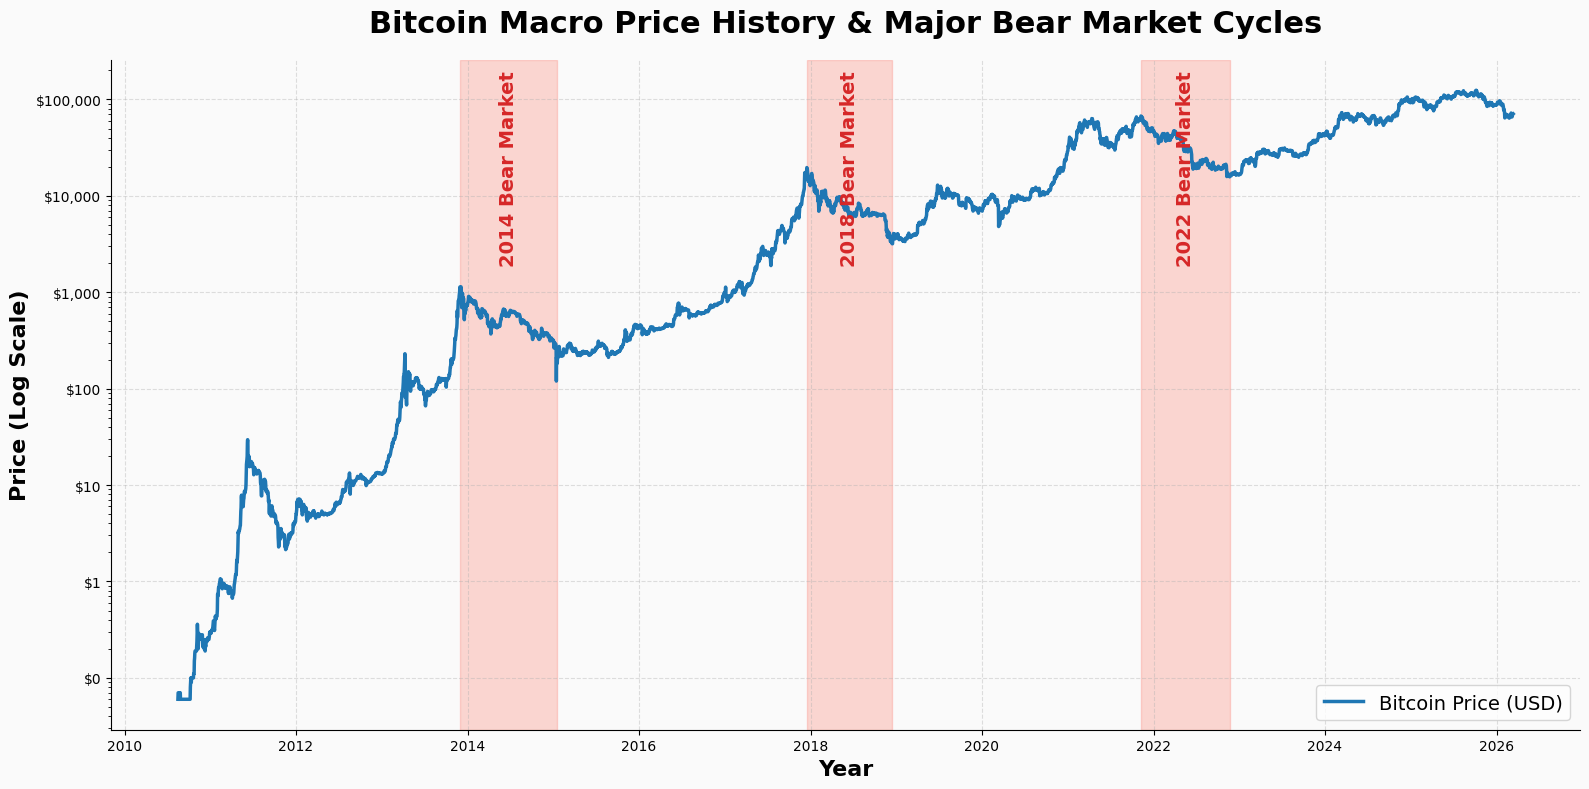

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
from pathlib import Path

# 1. Load the original full history dataset
original_data_path = Path("/Users/nguyenuyennguyen/Desktop/capstone_proj/stacksats/nguyen/csv_transform/bitcoin_analytics.parquet")
df = pd.read_parquet(original_data_path)
df['date'] = pd.to_datetime(df['date'])

# 2. Set up the plot aesthetics
plt.figure(figsize=(16, 8), facecolor='#FAFAFA')
ax = plt.gca()
ax.set_facecolor('#FAFAFA')

# 3. Plot the Bitcoin Price (using a Log Scale)
plt.plot(df['date'], df['price_usd'], color='#1f77b4', linewidth=2.5, label='Bitcoin Price (USD)')
plt.yscale('log') # Log scale is required to see 2010-2016 properly

# 4. Highlight the Major 1-Year Bear Markets
bear_markets = [
    {'start': '2013-12-01', 'end': '2015-01-15', 'name': '2014 Bear Market'},
    {'start': '2017-12-17', 'end': '2018-12-15', 'name': '2018 Bear Market'},
    {'start': '2021-11-10', 'end': '2022-11-21', 'name': '2022 Bear Market'}
]

for bear in bear_markets:
    start_date = pd.to_datetime(bear['start'])
    end_date = pd.to_datetime(bear['end'])
    
    # Add a transparent red/orange vertical band
    plt.axvspan(start_date, end_date, color='salmon', alpha=0.3)
    
    # Add text label in the middle of the band
    mid_date = start_date + (end_date - start_date) / 2
    
    # We place the text high up on the log scale (around $100,000 to $500,000)
    plt.text(mid_date, 200000, bear['name'], color='#d62728', 
             fontsize=14, fontweight='bold', ha='center', va='top', rotation=90)

# 5. Formatting
plt.title('Bitcoin Macro Price History & Major Bear Market Cycles', fontsize=22, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=16, fontweight='bold')
plt.ylabel('Price (Log Scale)', fontsize=16, fontweight='bold')

# Format Y-axis to show real dollar amounts instead of scientific notation
formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# Clean up borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(True, which="major", ls="--", alpha=0.4)
plt.legend(loc='lower right', fontsize=14)
plt.tight_layout()

plt.show()
